RMSE: 0.0001507923005170764
R2 Score: 0.0


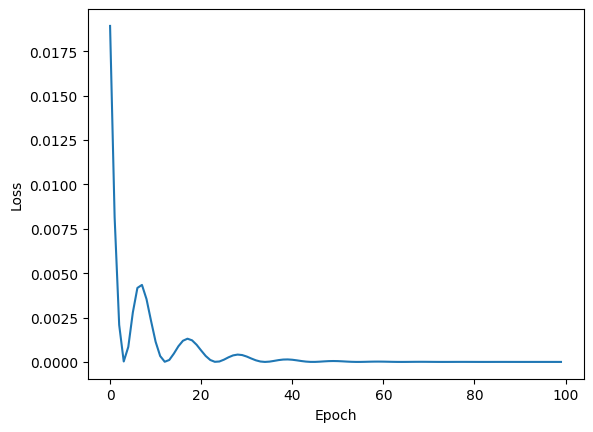

In [6]:
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np # Import numpy for nan_to_num

df = pd.read_csv("/content/weatherHistory-selected-columns.csv")

# Impute missing numerical values
for col in df.select_dtypes(include=['number']).columns:
    if df[col].isnull().any():
        # If the column is entirely NaN, fill with 0, otherwise fill with mean
        if df[col].isnull().all():
            df[col] = df[col].fillna(0)
        else:
            df[col] = df[col].fillna(df[col].mean())

# Impute missing categorical values and encode
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        # If the column is entirely NaN, fill with a placeholder string 'missing'
        # otherwise fill with the mode.
        if df[col].isnull().all():
            df[col] = df[col].fillna('missing')
        else:
            # Check if mode() is empty (e.g., if all unique values are NaN)
            if not df[col].mode().empty:
                df[col] = df[col].fillna(df[col].mode()[0])
            else: # Fallback if mode is empty even if not all NaN (unlikely for object dtype)
                df[col] = df[col].fillna('missing')
    df[col] = LabelEncoder().fit_transform(df[col])

# As a final safeguard, if any NaNs somehow remain, drop those rows.
df.dropna(inplace=True)

# Add a check for an empty DataFrame after all preprocessing
if df.empty:
    raise ValueError("DataFrame is empty after handling missing values. No valid data to train the model.")

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.reshape(-1,1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Convert to FloatTensor. Using .nan_to_num for robustness in case NaNs slipped through StandardScaler
X_train=torch.nan_to_num(torch.FloatTensor(X_train))
X_test=torch.nan_to_num(torch.FloatTensor(X_test))
y_train=torch.nan_to_num(torch.FloatTensor(y_train))
y_test=torch.nan_to_num(torch.FloatTensor(y_test))

model=nn.Sequential(
    nn.Linear(X_train.shape[1],32),
    nn.ReLU(),
    nn.Linear(32,1)
)

loss_fn=nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

losses=[]

for epoch in range(100):
    pred=model(X_train)
    loss=loss_fn(pred,y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

pred=model(X_test).detach().numpy()

# Ensure predictions are free of NaNs before computing metrics
pred = np.nan_to_num(pred)

print("RMSE:",mean_squared_error(y_test,pred)**0.5)
print("R2 Score:",r2_score(y_test,pred))

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()